# **Classification Fine Tuning**

## **Prepare Dataset**
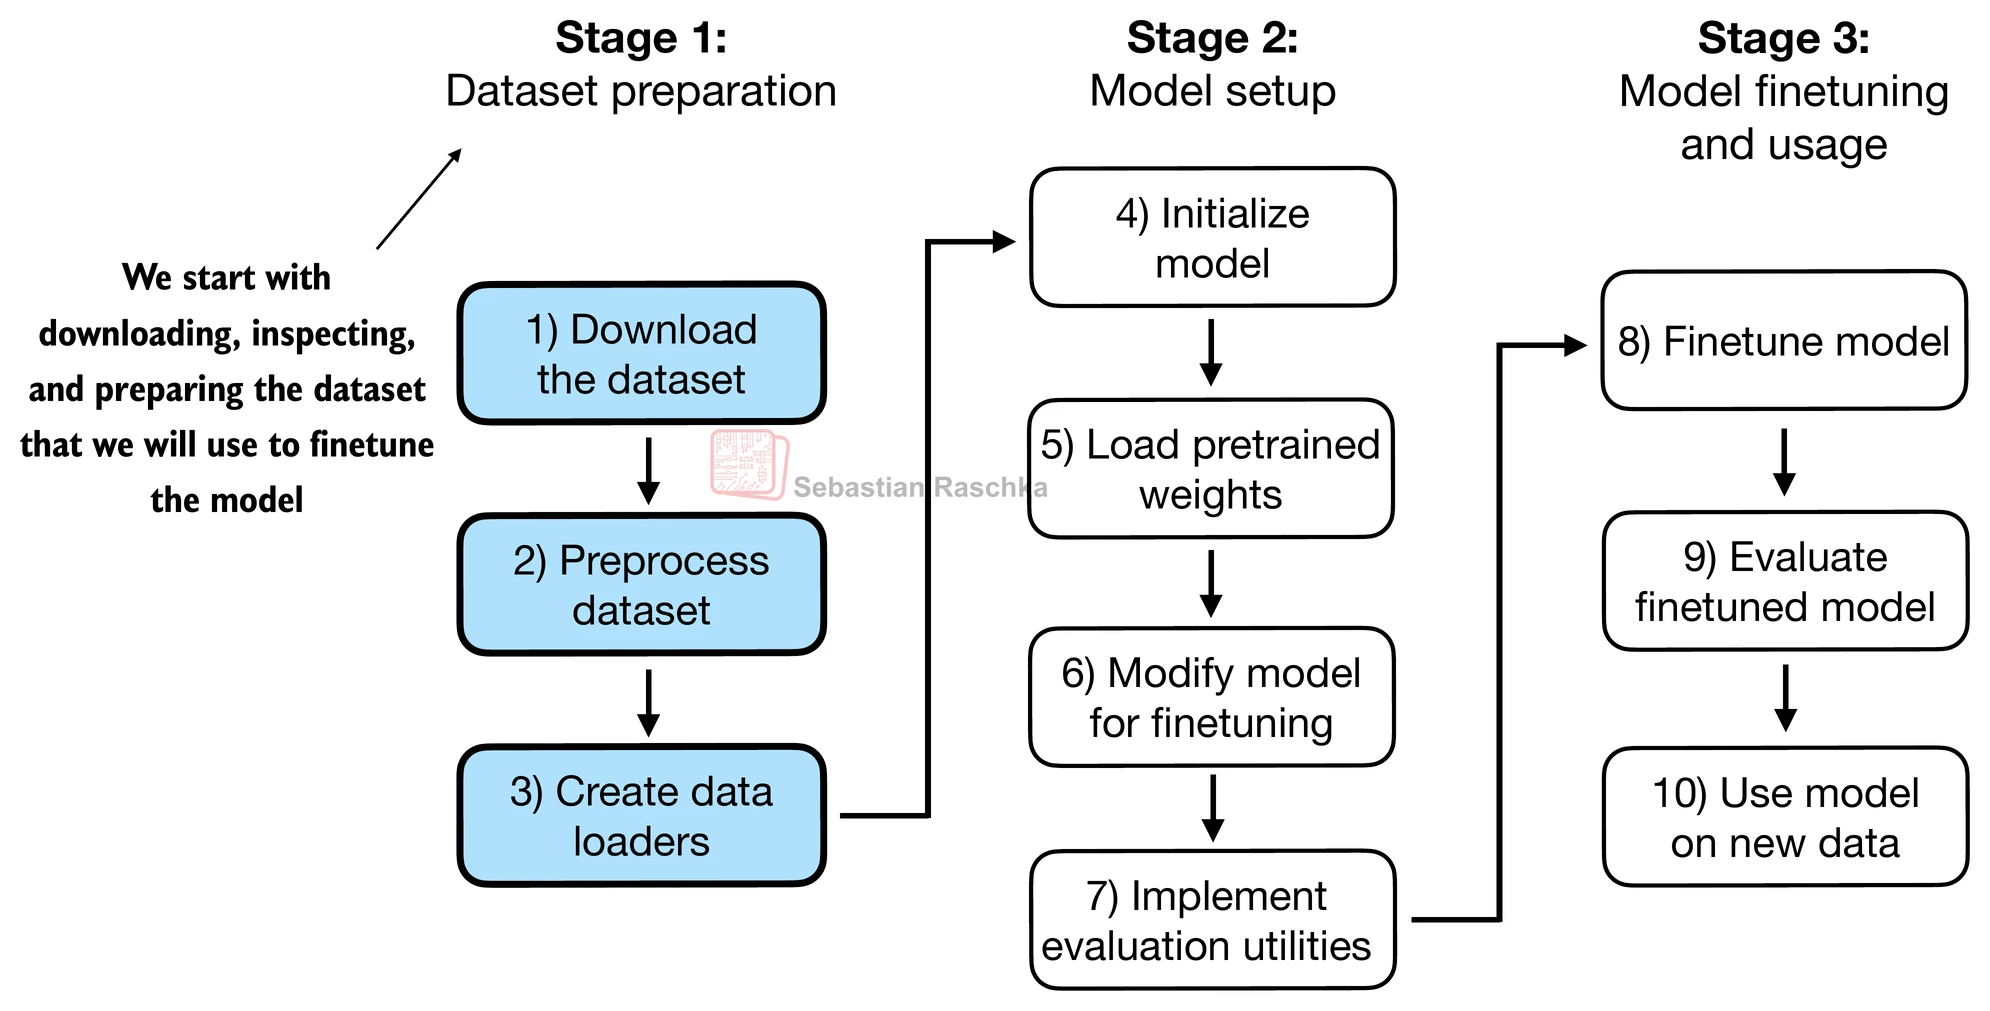

In [2]:
import pandas as pd

data_file_path = r"..\sms_spam_collection\SMSSpamCollection.tsv"

df = pd.read_csv(
    data_file_path, sep="\t", header = None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


There are significantly more non spam than spam in the data therefore we need to undersamples and make it balanced 

In [ ]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]

    #randomly sample ham messages to match the number of spam messages
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )

    #combine the samp ham messages with spam messages 
    balanced_df = pd.concat([
        ham_subset,
        df[df["Label"] == "spam"]
    ])

    return balanced_df 

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


Similar to converting text into tokens we need to do the same but convert ham -> 0 and spam -> 1. (String-> Integer)

In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [7]:
from Classif_Fine_tuning import random_split

train_df, val_df, test_df = random_split(balanced_df, 0.7, 0.1)

#save them
train_df.to_csv("train.csv", index=None)
val_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)


## **Creating Data loaders**

previous we used a sliding window method where the numebr of token would be consistent for more efficient model training. However unlike before, you can't just split is as the text messages are different in length.

2 options:
1. truncate messages to shortest -> info loss = bad training
2. pad all messages to longest message -> using <|endoftext|> (token ID = 50256) as padding 
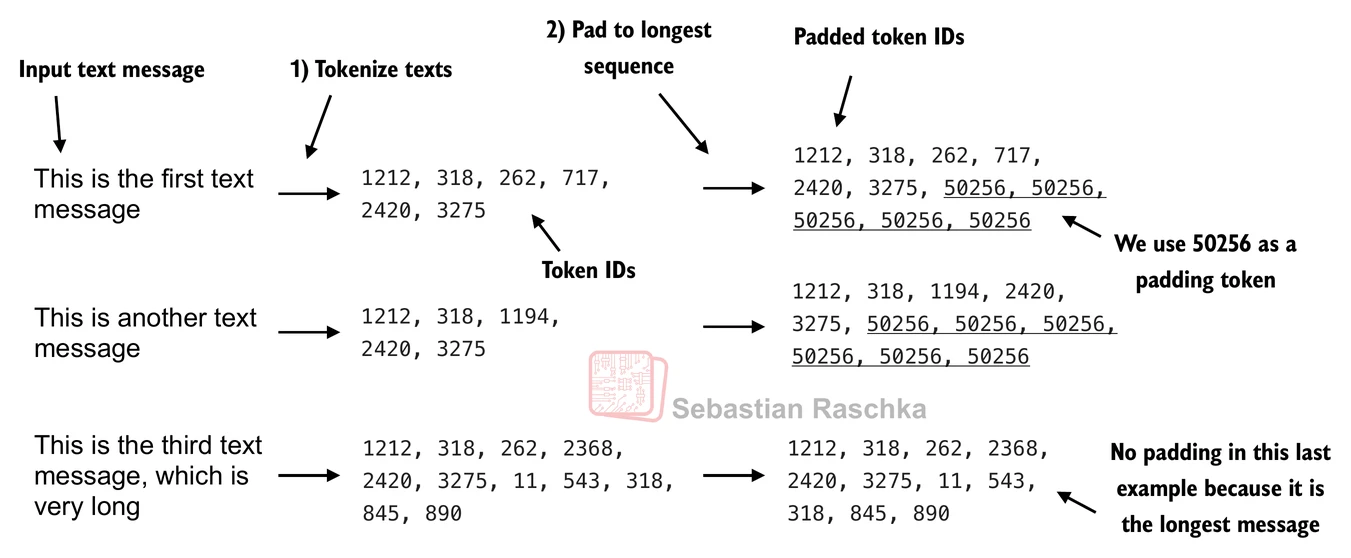

In [4]:
from Classif_Fine_tuning import SpamDataset
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

train_dataset = SpamDataset(
    csv_file = "train.csv",
    max_length = None,
    tokenizer = tokenizer
)

TypeError: unsupported operand type(s) for -: 'NoneType' and 'int'